# Tutorial 2: PyTorch — Tensors, Autograd, Regression, and Classification

Course: **Applied Deep Learning (ECE1553) - FALL 2026**
Instructor: **Dr. Ali Breyhi**
Tutorial: **Saleh Tabatabaei**

### Learning goals
By the end of this tutorial, you should be able to:
1. Create, inspect, reshape, and perform basic operations with **PyTorch tensors**.
2. Use **linear regression in PyTorch** and understand the training loop.
3. Explain how **Autograd** builds and differentiates through a computational graph.
4. Recognize the roles of `nn.Module`, `nn.Linear`, and `nn.Sequential`.
5. Choose between **MSE**, **BCE**, and **CrossEntropy** losses for common tasks.
6. Build and train a small **MLP classifier**.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim   # Optimizer: SGD, Adam
import numpy as np
import matplotlib.pyplot as plt

# Part 1: Tensor Operations

In [9]:
# Create tensors from list
data_list = [1.0, 2.0, 3.0]
x = torch.tensor(data_list)
x

tensor([1., 2., 3.], dtype=torch.float64)

In [10]:
# Create tensors from numpy array
# Pay attention to the data dtype torch.float64, different from x.
y_np = np.array(data_list)
y = torch.from_numpy(y_np)
y

Addition:  tensor([2., 4., 6.], dtype=torch.float64)


In [11]:
# Basic operations
print("Addition: ", x + y)

Element-wise Multiplication:  tensor([1., 4., 9.], dtype=torch.float64)


In [12]:
print("Element-wise Multiplication: ", x * y)

In [13]:
# Common mistakes: dot product on different data types
# RuntimeError: dot : expected both vectors to have same dtype, but found Float and Double
print("Dot product: ", torch.dot(x, y))  

x.dtype: torch.float32
y.dtype: torch.float64


In [14]:
print("x.dtype:", x.dtype)
print("y.dtype:", y.dtype)


x.dtype: torch.float64
Dot product:  tensor(14., dtype=torch.float64)


In [15]:
# Convert tensor x's data type to the same type of tensor y
x = x.to(y.dtype)
print("x.dtype:", x.dtype)

# Now we can do dot product without error
print("Dot product: ", torch.dot(x, y))

torch.dot(x, y):  tensor(14., dtype=torch.float64)
x @ y:  tensor(14., dtype=torch.float64)


In [16]:
# Different ways of doing dot product
print("torch.dot(x, y): ", torch.dot(x, y))
print("x @ y: ", x @ y)

Original Tensor:
 tensor([[ 0.0158,  1.7430,  1.0857],
        [ 0.7862, -0.3632,  1.1915]])
Reshaped Tensor by view:
 tensor([[ 0.0158,  1.7430],
        [ 1.0857,  0.7862],
        [-0.3632,  1.1915]])


In [17]:
# Reshaping tensors
a = torch.randn(2, 3)
print("Original Tensor:\n", a)

b = a.view(3, 2)
print("Reshaped Tensor by view:\n", b)

Reshaped Tensor by reshape:
 tensor([[ 0.0158,  1.7430],
        [ 1.0857,  0.7862],
        [-0.3632,  1.1915]])
Are b and c equal? True


In [18]:
c = a.reshape(3, 2)
print("Reshaped Tensor by reshape:\n", c)

# b and c are equal
print("Are b and c equal?", torch.allclose(b, c))

Reshaped Tensor by transpose:
 tensor([[ 0.0158,  0.7862],
        [ 1.7430, -0.3632],
        [ 1.0857,  1.1915]])
Are c and d equal? False


In [19]:
# Transpose
d = a.t()
print("Reshaped Tensor by transpose:\n", d)
print("Are c and d equal?", torch.allclose(c, d))

mean of all tensor entries tensor(0.7432)
mean of tensor entries along axis=0 tensor([0.4010, 0.6899, 1.1386])
mean of tensor entries along axis=1 tensor([0.9482, 0.5382])


In [20]:
print("mean of all tensor entries", a.mean())
print("mean of tensor entries along axis=0", a.mean(axis=0))
print("mean of tensor entries along axis=1", a.mean(axis=1))

sum of all tensor entries tensor(4.4590)
sum of tensor entries along axis=0 tensor([0.8020, 1.3797, 2.2772])
sum of tensor entries along axis=1 tensor([2.8445, 1.6145])


In [ ]:
print("sum of all tensor entries", a.sum())
print("sum of tensor entries along axis=0", a.sum(axis=0))
print("sum of tensor entries along axis=1", a.sum(axis=1))

# Part 2: Linear Regression in PyTorch

**NEW — ~8 min**

We now use tensors, gradients, a loss function, and an optimizer together.

For a simple linear regression model,

$$\hat{y} = wx + b$$

we learn the parameters `w` and `b` by minimizing the mean squared error (MSE):

$$\mathrm{MSE} = \frac{1}{N}\sum_i (\hat{y}_i-y_i)^2$$

The important idea is the same one we will use for neural networks:
**forward pass → loss → backward pass → parameter update**.

In [22]:
# NEW: Create a small synthetic regression dataset.
# The true relationship is approximately y = 3x + 2, with a little noise.

torch.manual_seed(0)

X_reg = torch.linspace(-2, 2, 40).unsqueeze(1)
y_reg = 3 * X_reg + 2 + 0.3 * torch.randn_like(X_reg)

print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

Learned w: 3.033
Learned b: 1.976
Final MSE: 0.080


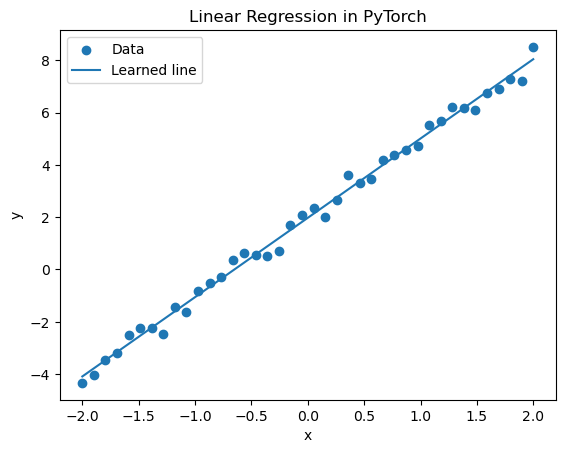

In [23]:
# NEW: Define a linear model directly with trainable tensors.
# requires_grad=True tells Autograd to track operations involving these parameters.

w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

learning_rate = 0.05
num_epoch = 1000
loss_values_reg = []

for epoch in range(num_epoch):
    # Forward pass: make predictions.
    y_pred = w * X_reg + b

    # MSE loss measures the squared difference between predictions and targets.
    loss = torch.mean((y_pred - y_reg) ** 2)

    # Backward pass: compute d(loss)/dw and d(loss)/db.
    loss.backward()

    # Update parameters without tracking the update in the computation graph.
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # Clear gradients before the next iteration.
    w.grad.zero_()
    b.grad.zero_()

    loss_values_reg.append(loss.item())

print(f"Learned w: {w.item():.3f}")
print(f"Learned b: {b.item():.3f}")
print(f"Final MSE: {loss_values_reg[-1]:.3f}")

In [ ]:
# NEW: Visualize the data and learned regression line.

plt.scatter(X_reg.numpy(), y_reg.numpy(), label="Data")
plt.plot(
    X_reg.numpy(),
    (w * X_reg + b).detach().numpy(),
    label="Learned line"
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression in PyTorch")
plt.legend()
plt.show()

### What to notice

- `w` and `b` are the **parameters** we want to learn.
- `requires_grad=True` allows Autograd to calculate their gradients.
- `loss.backward()` computes the gradients.
- `with torch.no_grad()` prevents the parameter update from becoming part of the graph.
- We manually update the parameters here so the connection to gradient descent is visible.
- Later, `torch.optim.SGD` will handle the update for us.

**Transition:** the neural-network examples below use exactly the same training pattern, but `nn.Module` manages the learnable parameters for us.

# Part 2: Autograd: Automatic differentiation

## Simple example: y = x^2

In [25]:
# Create a tensor that requires gradient computing
x = torch.tensor(1.0, requires_grad=True)

dy/dx @x=1: 2.0


In [ ]:
# function example: y = x^2


# Clear previous gradients, if exists
if x.grad is not None:
    x.grad.zero_()  # All PyTorch methods ending in underline _ are in-place operation.


# Forward propagation
y = x ** 2
# dy/dx = 2x
# Backward propagation
y.backward()

# Fetch gradient
gradient = x.grad


print(f"dy/dx @x=1: {gradient}")

## Dynamically tracing the computation

In [27]:
# PyTorch traces your computation by building a dynamic graph
# function example: z = x + y = x + x^2
x = torch.tensor(1.0, requires_grad=True)
y = x ** 2
y.retain_grad()
z = x + y
# dz/dx = 1 + 2x
# dz/dy = 1
z.backward()
print(f"dz/dx @x=1: {x.grad}")

tensor(1.)

In [28]:
y.grad

dy/dx @x=1 for nested function: tensor([2., 6., 0.])


In [ ]:
# Autograd also works for multi-variables
# y = 2*x0 + 3 (x1)^2
# dy/dx0 = 2
# dy/dx1 = 6x1

x = torch.tensor([1.0, 1.0, 1.0], requires_grad=True)
y = 2*x[0] + 3 * (x[1] ** 2)
y.backward()
print(f"dy/dx @x=1 for nested function: {x.grad}")


# Part 4: PyTorch Modules, Layers, and Loss Functions

**NEW — ~7 min**

PyTorch provides building blocks for neural networks:

- `nn.Module`: base class for neural-network models.
- `nn.Linear`: a fully connected layer that computes a linear transformation.
- `nn.Sequential`: a convenient way to chain layers in order.

A typical MLP can look like:

`input → Linear → activation → Linear → output`

The model's parameters are registered automatically when layers are stored inside an `nn.Module`.

In [30]:
# NEW: A minimal example of nn.Linear.
# Here, each input has 2 features and the layer produces 3 outputs.

linear_layer = nn.Linear(in_features=2, out_features=3)

sample = torch.tensor([[1.0, 2.0]])
output = linear_layer(sample)

print("Input shape:", sample.shape)
print("Output shape:", output.shape)
print("Learnable parameters:")
for name, parameter in linear_layer.named_parameters():
    print(name, parameter.shape)

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
)
Number of trainable parameters: 17


In [ ]:
# NEW: nn.Sequential lets us define a small MLP without writing
# a custom forward() method.

small_mlp = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)

print(small_mlp)
print("Number of trainable parameters:",
      sum(p.numel() for p in small_mlp.parameters()))

## Loss functions: MSE, BCE, and CrossEntropy

The loss function depends on the learning task:

| Loss | Typical use | Target / output setup |
|---|---|---|
| `nn.MSELoss()` | Regression | Continuous target, e.g. 2.7 |
| `nn.BCELoss()` | Binary classification | Target 0/1 and model output is a probability |
| `nn.CrossEntropyLoss()` | Multi-class classification | Target is a class index; model outputs **logits** |

The key distinction for classification is that `CrossEntropyLoss` expects **raw logits**, so we do **not** apply `Softmax` before passing predictions to the loss.

In [ ]:
# NEW: MSELoss — regression
mse = nn.MSELoss()

regression_prediction = torch.tensor([2.5, 4.0])
regression_target = torch.tensor([3.0, 5.0])

print("MSE:", mse(regression_prediction, regression_target).item())

# NEW: BCELoss — binary classification.
# BCELoss expects probabilities in [0, 1].
bce = nn.BCELoss()

binary_probability = torch.tensor([0.8, 0.2])
binary_target = torch.tensor([1.0, 0.0])

print("BCE:", bce(binary_probability, binary_target).item())

# NEW: CrossEntropyLoss — multi-class classification.
# These are raw scores (logits), not probabilities.
ce = nn.CrossEntropyLoss()

logits = torch.tensor([
    [2.0, 0.5, -1.0],
    [-0.5, 1.5, 0.2]
])
class_targets = torch.tensor([0, 1])

print("CrossEntropy:", ce(logits, class_targets).item())

### A useful shape check

For a batch of `N` samples:

- Binary classifier with one output: often `logits.shape == (N, 1)`.
- Multi-class classifier with `C` classes: `logits.shape == (N, C)`.
- `CrossEntropyLoss` targets are class indices with shape `(N,)`, e.g. `[0, 2, 1, ...]`.

**Common mistake:** applying `softmax` before `CrossEntropyLoss`. For a standard PyTorch classifier, pass the raw logits directly to `CrossEntropyLoss`.

# Part 3: Optimize a squared function gradient descent via Autograd

In [33]:
def dummy_loss_function(x):
    '''
    x: a tensor that x.requires_grad=True
    '''

    l = (x[0]-3) ** 2 + (x[1]-5) ** 2

    return l

tensor([-4., -8.])

In [ ]:
x = torch.tensor([1.0, 1.0], requires_grad=True)

# x.grad.zero_()
dummy_loss_function(x).backward()

x.grad

### Manually update variables

In [ ]:
# Initialize the variables
x = torch.tensor([1.0, 1.0], requires_grad=True)
learning_rate = 0.1
num_epoch = 30

loss_values = []

# Perform gradient descent for num_epoch iterations
for _ in range(num_epoch):
    loss = dummy_loss_function(x)
    loss.backward()

    # Turn off tracing the computation using "with torch.no_grad()"
    with torch.no_grad():
        # Apply gradient descent manually
        x -= learning_rate * x.grad
        x.grad.zero_()

    # Record loss value
    loss_values.append(loss.item())

# Generate the plots
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

# Plot learning curve (loss over epochs)
ax1.plot(range(1, num_epoch+1), loss_values, marker='o', linestyle='-', color='b')
ax1.set_title('Learning Curve: Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
plt.tight_layout()
plt.show()

print(f"Optimized x: {x} (Analytical solution is x=[3, 5])")

### Automatically update variables via PyTorch Optimizers

In [ ]:
# Initialize x as a tensor with requires_grad=True
x = torch.tensor([1.0, 1.0], requires_grad=True)
num_epoch = 30

# Define the SGD optimizer
optimizer = torch.optim.SGD([x], lr=0.1)

# Store values for plotting
loss_values = []

# Optimization loop using the optimizer
for epoch in range(num_epoch):
    # Zero the gradients from the previous step
    optimizer.zero_grad()

    # Compute the loss
    loss = dummy_loss_function(x)
    
    # Backpropagate the gradients
    loss.backward()

    # Update the value of x using the optimizer
    optimizer.step()

    # Record loss value
    loss_values.append(loss.item())

# Generate the plots
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

# Plot learning curve (loss over epochs)
ax1.plot(range(1, num_epoch+1), loss_values, marker='o', linestyle='-', color='b')
ax1.set_title('Learning Curve: Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
plt.tight_layout()
plt.show()

print(f"Optimized x: {x} (Analytical solution is x=[3, 5])")


### The standard PyTorch training loop

The optimizer example above gives us the template used throughout deep learning:

1. `optimizer.zero_grad()`
2. **Forward:** `output = model(X)`
3. **Loss:** `loss = criterion(output, y)`
4. **Backward:** `loss.backward()`
5. **Update:** `optimizer.step()`

Keep this five-step pattern in mind while reading the classifier below.

# Part 4: Binary Classification using Neural Networks

## Generate Synthetic Data

In [ ]:
def make_dataset(N):
    radius = 5
    X = torch.zeros((N, 2))
    y = torch.zeros(N)
    
    # Inner
    r = torch.distributions.Uniform(0, radius*0.5).sample([1, N // 2])
    angle = torch.distributions.Uniform(0, 2*np.pi).sample([1, N // 2])
    X[:N // 2, 0] = r * torch.cos(angle)
    X[:N // 2, 1] = r * torch.sin(angle)
    y[:N // 2] = 1

    # Outer

    r = torch.distributions.Uniform(radius*0.7, radius).sample([1, N // 2])
    angle = torch.distributions.Uniform(0, 2*np.pi).sample([1, N // 2])
    X[N // 2:, 0] = r * torch.cos(angle)
    X[N // 2:, 1] = r * torch.sin(angle)
    y[N // 2:] = 0
    
    return X, y

N = 500
X, y = make_dataset(N)

# Red labels are 1, blue labels are 0
plt.scatter(X[:N // 2, 0], X[:N // 2, 1], color='red')
plt.scatter(X[N// 2:, 0], X[N//2:, 1], color='blue')
plt.show()

## Build Classifier Model (Neural Network)

In [38]:
# nn.Module Brief Explanation:
# nn.Module is a base class for all neural network modules.
# Custom models are usually created by subclassing nn.Module and defining layers in the __init__ method.
# The forward method defines how data is passed through the layers.


class BinaryClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=3, output_dim=1):
        super(BinaryClassifier, self).__init__()

        # fully connected layer
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, output_dim)

    # Override the forward method in nn.Module
    def forward(self, x):
        y1 = torch.tanh(self.layer1(x))
        y2 = torch.sigmoid(self.layer2(y1))
        return y2

In [39]:
# Equivalent definition to the BinaryClassifier class above, using nn.Sequential()
class BinaryClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=3, output_dim=1):
        super(BinaryClassifier, self).__init__()

        # Define the model using nn.Sequential
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),   # Fully connected layer 1
            nn.Tanh(),                          # Activation function (Tanh)
            nn.Linear(hidden_dim, output_dim),   # Fully connected layer 2
            nn.Sigmoid()                        # Activation function (Sigmoid)
        )

    # Override the forward method in nn.Module
    def forward(self, x):
        return self.model(x)

Parameter containing:
tensor([[ 0.3074, -0.0601],
        [-0.0436, -0.4435],
        [-0.2558,  0.4595]], requires_grad=True)
Parameter containing:
tensor([-0.2835,  0.4391, -0.2804], requires_grad=True)
Parameter containing:
tensor([[-0.1345,  0.0123, -0.5298]], requires_grad=True)
Parameter containing:
tensor([-0.0058], requires_grad=True)


In [ ]:
for p in BinaryClassifier().parameters():
    print(p)

## Training pipeline

In [ ]:
# Prepare datasets
X, y = make_dataset(N=500)

# Create prediction model instance
model = BinaryClassifier()

# create binary cross entropy loss
criterion = nn.BCELoss()

# create an optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)

num_epoch = 10000

loss_values = []

# Training loop
for epoch in range(num_epoch):
    model.train()  # set to train mode: requires_grad=True

    # clears previous gradient
    optimizer.zero_grad()
    
    # Forward propagation
    output = model(X).squeeze()
    loss = criterion(output, y)
    
    # Backward propagation
    loss.backward()

    # Update weights
    optimizer.step()
        
    # Record loss value
    loss_values.append(loss.item())

# Generate the plots
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

# Plot learning curve (loss over epochs)
ax1.plot(range(1, num_epoch+1), loss_values, marker='o', linestyle='-', color='b')
ax1.set_title('Learning Curve: Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
plt.tight_layout()
plt.show()

print("Training complete")

## Plot decision boundary of the learned classifier

In [ ]:
num_points = 200
x1s = torch.linspace(-6.0, 6.0, num_points)
x2s = torch.linspace(-6.0, 6.0, num_points)

X1, X2 = torch.meshgrid(x1s, x2s, indexing="ij")
points = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)

Y = torch.sigmoid(model(torch.Tensor(points)))
# Y = model(torch.Tensor(points))
Y = Y.detach().numpy().reshape(num_points, num_points)

plt.pcolormesh(X1, X2, Y, cmap=plt.colormaps['coolwarm'])
plt.colorbar()
plt.scatter(X[:N // 2, 0], X[:N // 2, 1], color='red')
plt.scatter(X[N// 2:, 0], X[N//2:, 1], color='blue')
plt.show()

# Part 5: Build and Train an MLP Classifier

**NEW — optional extension **

The original tutorial already builds a **binary MLP classifier** using `nn.Module`, `nn.Linear`, `nn.Sequential`, `Sigmoid`, `BCELoss`, and SGD. The following short example shows the same ideas for **multi-class classification**, where `CrossEntropyLoss` is used.

In [43]:
# NEW: Three-class toy dataset.
# Each point is assigned to one of three classes based on its location.

torch.manual_seed(1)

X_multi = torch.tensor([
    [0.0, 0.0], [0.2, 0.1], [-0.2, 0.1],      # class 0
    [2.0, 0.0], [2.2, 0.2], [1.8, -0.1],       # class 1
    [1.0, 2.0], [1.2, 2.1], [0.8, 1.9]         # class 2
])
y_multi = torch.tensor([0, 0, 0, 1, 1, 1, 2, 2, 2])

print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

Final loss: 0.0087
Training accuracy: 100.0%


In [ ]:
# NEW: MLP for 3-class classification.
# Important: there is NO Softmax at the end.
# CrossEntropyLoss operates directly on the output logits.

class MultiClassMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.model(x)

multi_model = MultiClassMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(multi_model.parameters(), lr=0.1)

for epoch in range(500):
    optimizer.zero_grad()

    # Forward pass: output shape is (N, 3) = one logit per class.
    logits = multi_model(X_multi)

    # CrossEntropyLoss compares logits with integer class labels.
    loss = criterion(logits, y_multi)

    loss.backward()
    optimizer.step()

# Convert logits to predicted class indices.
predicted_classes = multi_model(X_multi).argmax(dim=1)

accuracy = (predicted_classes == y_multi).float().mean()
print(f"Final loss: {loss.item():.4f}")
print(f"Training accuracy: {accuracy.item() * 100:.1f}%")

## Wrap-up: connect the pieces

The tutorial has now used the same core ideas at increasing levels of abstraction:

**Tensors → Autograd → Gradient descent → `nn.Module` / `nn.Linear` → Loss → Optimizer → MLP**

### Quick check before Q&A
- Why do we call `optimizer.zero_grad()`?
- What does `loss.backward()` compute?
- Why does the binary example use `Sigmoid` + `BCELoss`?
- Why does the multi-class example use raw logits + `CrossEntropyLoss`?
- Where are the trainable parameters stored in an `nn.Module`?